In [1]:
import time
import random
from pathlib import Path

import requests
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"

IMAGES_PER_CLASS = 1500
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR = 1e-3
TEST_SIZE = 0.2
VAL_SIZE = 0.1

DEVICE = torch.device("cuda")


In [2]:
SESSION = requests.Session()
SESSION.headers.update({
    "user-agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0 Safari/537.36",
    "accept": "application/json, text/plain, */*",
})


def inat_get(url: str, params: dict, timeout: int = 20, retries: int = 5, backoff: float = 0.6):
    for i in range(retries):
        try:
            resp = SESSION.get(url, params=params, timeout=timeout)
            resp.raise_for_status()
            return resp.json()
        except requests.RequestException:
            if i == retries - 1:
                raise
            time.sleep(backoff * (2 ** i))


def get_taxon_id(name: str):
    data = inat_get("https://api.inaturalist.org/v1/taxa", {"q": name, "rank": "species"})
    results = data.get("results", [])
    if not results:
        raise ValueError(f"Taxon not found: {name}")
    return results[0]["id"]


def photo_url(photo: dict, size: str = "large"):
    url = photo.get("url", "")
    if not url:
        return ""
    return url.replace("square", size)


def iter_observations(taxon_id: int, need: int, per_page: int = 200):
    page = 1
    collected = []
    while len(collected) < need:
        data = inat_get(
            "https://api.inaturalist.org/v1/observations",
            {
                "taxon_id": taxon_id,
                "photos": True,
                "quality_grade": "research",
                "per_page": per_page,
                "page": page,
                "order": "desc",
                "order_by": "created_at",
            },
        )
        results = data.get("results", [])
        if not results:
            break
        for item in results:
            if len(collected) >= need:
                break
            photos = item.get("photos", [])
            if not photos:
                continue
            url = photo_url(photos[0], size="large")
            if url:
                collected.append(url)
        page += 1
    return collected[:need]


In [3]:
CLASSES = {
    "red_fox": "red fox",
    "raccoon": "raccoon",
    "white_tailed_deer": "white-tailed deer",
}

RAW_DIR.mkdir(parents=True, exist_ok=True)

class_ids = {}
for label, name in CLASSES.items():
    class_ids[label] = get_taxon_id(name)


In [4]:
import io
from concurrent.futures import ThreadPoolExecutor, as_completed


def download_one(url: str, out_path: Path):
    try:
        resp = SESSION.get(url, timeout=20)
        if resp.status_code != 200:
            return False
        img = Image.open(io.BytesIO(resp.content)).convert("RGB")
        img.save(out_path)
        return True
    except Exception:
        return False


def download_images(label: str, urls: list, limit: int, max_workers: int = 4):
    target_dir = RAW_DIR / label
    target_dir.mkdir(parents=True, exist_ok=True)
    existing = list(target_dir.glob("*.jpg"))
    if len(existing) >= limit:
        return

    need = limit - len(existing)
    urls = urls[:need]
    tasks = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for i, url in enumerate(urls):
            out_path = target_dir / f"{len(existing)+i:05d}.jpg"
            tasks.append(ex.submit(download_one, url, out_path))
        for _ in tqdm(as_completed(tasks), total=len(tasks), desc=label):
            pass


for label in CLASSES:
    taxon_id = class_ids[label]
    urls = iter_observations(taxon_id, IMAGES_PER_CLASS)
    download_images(label, urls, IMAGES_PER_CLASS)


white_tailed_deer: 100%|██████████| 1500/1500 [01:08<00:00, 21.76it/s]


In [5]:
rows = []
for label in CLASSES:
    for p in (RAW_DIR / label).glob("*.jpg"):
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print(df['label'].value_counts())


label
red_fox              1500
raccoon              1500
white_tailed_deer    1500
Name: count, dtype: int64


In [6]:
train_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=SEED, stratify=df['label']
)
train_df, val_df = train_test_split(
    train_df, test_size=VAL_SIZE, random_state=SEED, stratify=train_df['label']
)

print("train", len(train_df), "val", len(val_df), "test", len(test_df))


train 3240 val 360 test 900


In [7]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class ImgDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.labels = sorted(self.frame['label'].unique())
        self.label_to_idx = {l: i for i, l in enumerate(self.labels)}

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = Image.open(row['path']).convert("RGB")
        x = self.transform(img)
        y = self.label_to_idx[row['label']]
        return x, y


train_ds = ImgDataset(train_df, train_tfms)
val_ds = ImgDataset(val_df, val_tfms)
test_ds = ImgDataset(test_df, val_tfms)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

num_classes = len(train_ds.labels)
print(train_ds.labels)


['raccoon', 'red_fox', 'white_tailed_deer']


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward_features(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

    def forward(self, x):
        feats = self.forward_features(x)
        return self.classifier(feats)


In [9]:
from torch.utils.tensorboard import SummaryWriter


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    preds = []
    targets = []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds.extend(out.argmax(1).cpu().numpy())
        targets.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(targets, preds)
    return avg_loss, acc


def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds = []
    targets = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            preds.extend(out.argmax(1).cpu().numpy())
            targets.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(targets, preds)
    return avg_loss, acc


In [11]:
model = SimpleCNN(num_classes).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

writer = SummaryWriter("runs/simple_cnn")

start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_dl, criterion, optimizer)
    vl_loss, vl_acc = eval_one_epoch(model, val_dl, criterion)
    writer.add_scalar("loss/train", tr_loss, epoch)
    writer.add_scalar("loss/val", vl_loss, epoch)
    writer.add_scalar("acc/train", tr_acc, epoch)
    writer.add_scalar("acc/val", vl_acc, epoch)
    print(f"epoch {epoch}: train {tr_loss:.4f}/{tr_acc:.3f} val {vl_loss:.4f}/{vl_acc:.3f}")

simple_time = time.time() - start
writer.close()
print("simple cnn time:", simple_time)


epoch 1: train 1.0833/0.396 val 1.0330/0.428
epoch 2: train 1.0520/0.429 val 1.0185/0.425
epoch 3: train 1.0392/0.451 val 1.0110/0.461
epoch 4: train 1.0080/0.476 val 0.9899/0.481
epoch 5: train 0.9962/0.481 val 1.0055/0.478
epoch 6: train 0.9832/0.491 val 0.9624/0.514
epoch 7: train 0.9701/0.506 val 1.0344/0.483
epoch 8: train 0.9628/0.518 val 0.9664/0.517
epoch 9: train 0.9503/0.519 val 0.9345/0.525
epoch 10: train 0.9479/0.527 val 0.9354/0.531
epoch 11: train 0.9418/0.527 val 0.9460/0.533
epoch 12: train 0.9385/0.532 val 0.9153/0.550
epoch 13: train 0.9421/0.526 val 0.9317/0.536
epoch 14: train 0.9242/0.544 val 0.9226/0.528
epoch 15: train 0.9207/0.542 val 0.9708/0.519
epoch 16: train 0.9321/0.536 val 0.9310/0.528
epoch 17: train 0.9283/0.538 val 0.9682/0.497
epoch 18: train 0.9193/0.553 val 0.9434/0.539
epoch 19: train 0.9169/0.546 val 0.9151/0.550
epoch 20: train 0.9102/0.546 val 0.9040/0.558
epoch 21: train 0.9045/0.551 val 0.9062/0.544
epoch 22: train 0.8994/0.551 val 0.8981/0.5

In [12]:
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(DEVICE)
        out = model(x)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_targets.extend(y.numpy())

print(classification_report(all_targets, all_preds, target_names=train_ds.labels, digits=3))


                   precision    recall  f1-score   support

          raccoon      0.484     0.843     0.615       300
          red_fox      0.561     0.413     0.476       300
white_tailed_deer      0.846     0.440     0.579       300

         accuracy                          0.566       900
        macro avg      0.630     0.566     0.557       900
     weighted avg      0.630     0.566     0.557       900



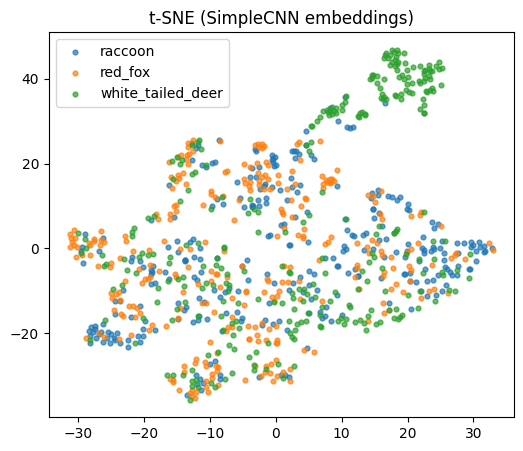

In [13]:
def extract_embeddings(model, loader):
    model.eval()
    feats = []
    labels = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            f = model.forward_features(x)
            feats.append(f.cpu().numpy())
            labels.extend(y.numpy())
    feats = np.concatenate(feats, axis=0)
    labels = np.array(labels)
    return feats, labels


emb, emb_labels = extract_embeddings(model, test_dl)

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
emb_2d = tsne.fit_transform(emb)

plt.figure(figsize=(6, 5))
for i, name in enumerate(train_ds.labels):
    idx = emb_labels == i
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], s=12, label=name, alpha=0.7)
plt.legend()
plt.title("t-SNE (SimpleCNN embeddings)")
plt.show()


In [14]:
def build_resnet(num_classes: int):
    backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in backbone.parameters():
        p.requires_grad = False
    in_features = backbone.fc.in_features
    backbone.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return backbone


resnet = build_resnet(num_classes).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=LR)

writer = SummaryWriter("runs/resnet_transfer")

start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(resnet, train_dl, criterion, optimizer)
    vl_loss, vl_acc = eval_one_epoch(resnet, val_dl, criterion)
    writer.add_scalar("loss/train", tr_loss, epoch)
    writer.add_scalar("loss/val", vl_loss, epoch)
    writer.add_scalar("acc/train", tr_acc, epoch)
    writer.add_scalar("acc/val", vl_acc, epoch)
    print(f"epoch {epoch}: train {tr_loss:.4f}/{tr_acc:.3f} val {vl_loss:.4f}/{vl_acc:.3f}")

resnet_time = time.time() - start
writer.close()
print("resnet time:", resnet_time)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


epoch 1: train 0.8614/0.600 val 0.6346/0.742
epoch 2: train 0.6880/0.699 val 0.6048/0.750
epoch 3: train 0.6612/0.719 val 0.5970/0.758
epoch 4: train 0.6448/0.711 val 0.5632/0.756
epoch 5: train 0.6078/0.740 val 0.5501/0.761
epoch 6: train 0.5999/0.739 val 0.5520/0.772
epoch 7: train 0.5787/0.759 val 0.5644/0.764
epoch 8: train 0.5620/0.753 val 0.5658/0.747
epoch 9: train 0.5548/0.761 val 0.5194/0.792
epoch 10: train 0.5384/0.766 val 0.5255/0.781
epoch 11: train 0.5370/0.765 val 0.5668/0.772
epoch 12: train 0.5111/0.785 val 0.5231/0.792
epoch 13: train 0.4970/0.798 val 0.5397/0.781
epoch 14: train 0.4886/0.799 val 0.5195/0.783
epoch 15: train 0.5035/0.796 val 0.5879/0.772
epoch 16: train 0.4986/0.792 val 0.5171/0.783
epoch 17: train 0.4792/0.798 val 0.6204/0.764
epoch 18: train 0.4731/0.798 val 0.5332/0.781
epoch 19: train 0.4597/0.800 val 0.5120/0.803
epoch 20: train 0.4480/0.806 val 0.5282/0.775
epoch 21: train 0.4351/0.815 val 0.5087/0.817
epoch 22: train 0.4269/0.828 val 0.5103/0.7

In [15]:
resnet.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(DEVICE)
        out = resnet(x)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_targets.extend(y.numpy())

print(classification_report(all_targets, all_preds, target_names=train_ds.labels, digits=3))


                   precision    recall  f1-score   support

          raccoon      0.808     0.783     0.795       300
          red_fox      0.778     0.830     0.803       300
white_tailed_deer      0.844     0.813     0.829       300

         accuracy                          0.809       900
        macro avg      0.810     0.809     0.809       900
     weighted avg      0.810     0.809     0.809       900



In [16]:
print("Compare training time (sec):")
print("simple cnn:", round(simple_time, 2))
print("resnet transfer:", round(resnet_time, 2))


Compare training time (sec):
simple cnn: 1732.71
resnet transfer: 1573.33
